# Retail Sales & Customer Behavior Analysis — Realmart

## Objective
Analyze retail sales data to understand branch performance, city-wise sales, product-line performance, payment preferences, customer satisfaction, and relationships between numerical variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Load and Inspect Dataset

In [2]:
df = pd.read_csv("../data/Retailmart_Raw_Dataset.csv")

print("Dataset Shape:", df.shape)

display(df.head())
display(df.tail())

df.info()

Dataset Shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

## 2. Data Cleaning

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert numerical columns
numeric_cols = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Total",
    "cogs",
    "gross income",
    "Rating"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nCleaning completed.")
print("Final shape:", df.shape)

Missing values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Duplicate rows: 0

Cleaning completed.
Final shape: (1000, 17)


## 3. Date Analysis

In [4]:
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month

monthly_sales = (
    df.groupby(["Month_Number", "Month"])["Total"]
      .sum()
      .reset_index()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Total
0,1,January,116291.868
1,2,February,97219.374
2,3,March,109455.507


## 4. GroupBy Business Analysis

In [5]:
sales_by_branch = (
    df.groupby("Branch")["Total"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_city = (
    df.groupby("City")["Total"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_product = (
    df.groupby("Product line")["Total"]
      .sum()
      .sort_values(ascending=False)
)

rating_by_branch = (
    df.groupby("Branch")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

payment_usage = df["Payment"].value_counts()

print("=== SALES BY BRANCH ===")
display(sales_by_branch)

print("=== SALES BY CITY ===")
display(sales_by_city)

print("=== SALES BY PRODUCT LINE ===")
display(sales_by_product)

print("=== AVERAGE RATING BY BRANCH ===")
display(rating_by_branch)

print("=== PAYMENT METHOD USAGE ===")
display(payment_usage)

=== SALES BY BRANCH ===


Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64

=== SALES BY CITY ===


City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Total, dtype: float64

=== SALES BY PRODUCT LINE ===


Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

=== AVERAGE RATING BY BRANCH ===


Branch
C    7.072866
A    7.027059
B    6.818072
Name: Rating, dtype: float64

=== PAYMENT METHOD USAGE ===


Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

## 5. Visualizations

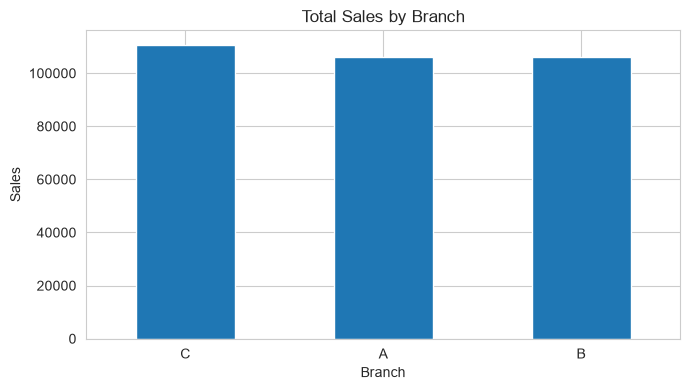

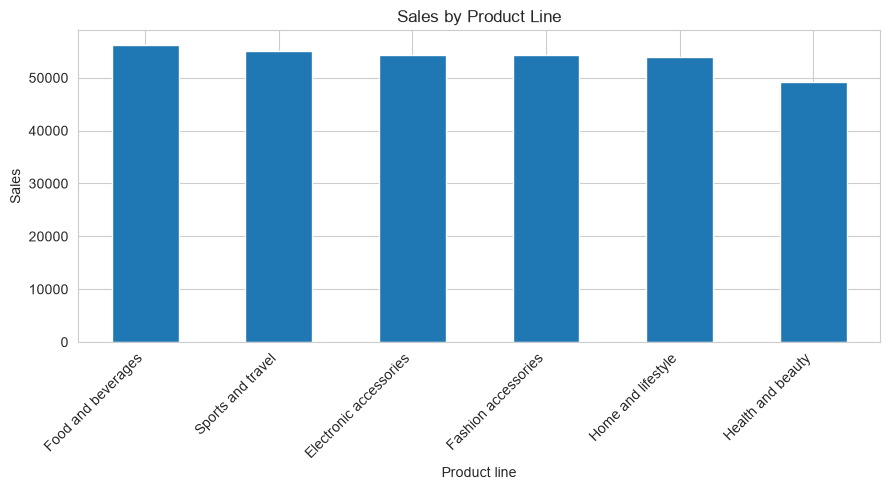

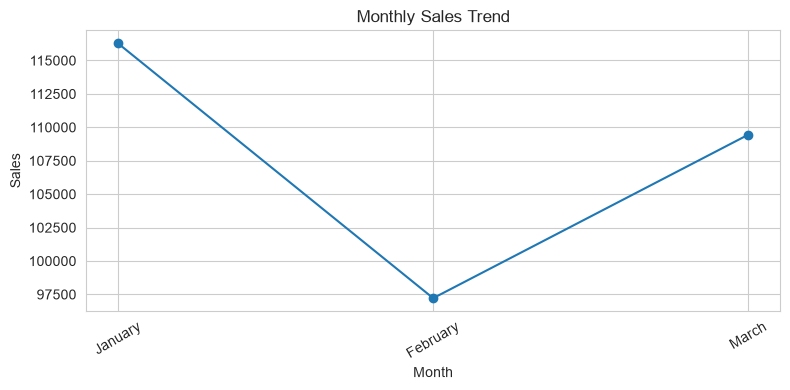

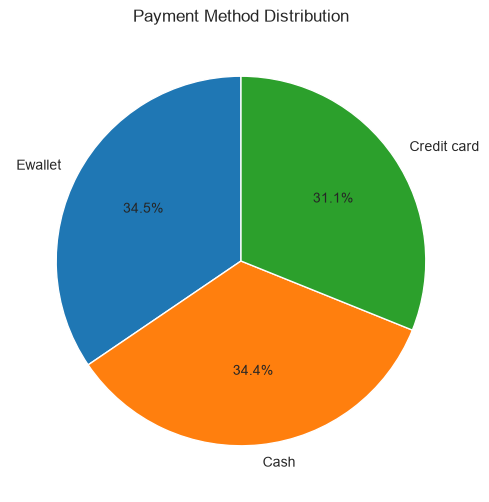

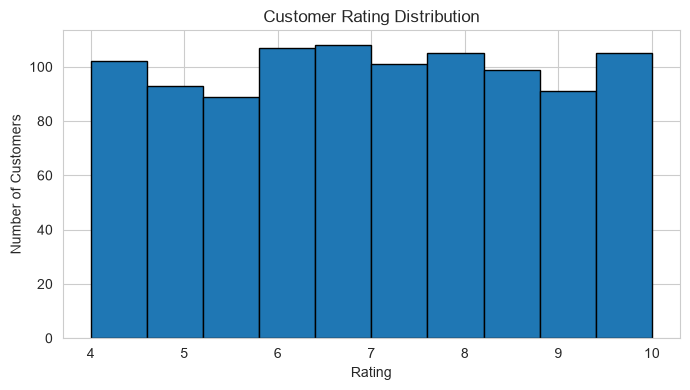

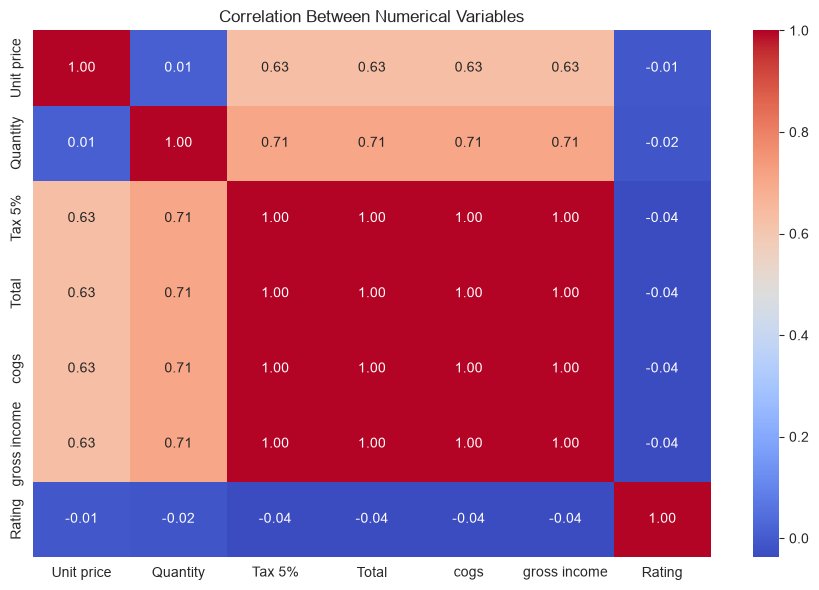

In [6]:
# 1. Sales by Branch
plt.figure(figsize=(7,4))
sales_by_branch.plot(kind="bar")
plt.title("Total Sales by Branch")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Sales by Product Line
plt.figure(figsize=(9,5))
sales_by_product.plot(kind="bar")
plt.title("Sales by Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. Monthly Sales Trend
plt.figure(figsize=(8,4))
plt.plot(monthly_sales["Month"], monthly_sales["Total"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 4. Payment Method Distribution
plt.figure(figsize=(6,6))
payment_usage.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# 5. Customer Rating Distribution
plt.figure(figsize=(7,4))
plt.hist(df["Rating"], bins=10, edgecolor="black")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 6. Correlation Heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

## 6. Key Results

In [7]:
print("1. Highest Revenue Branch:")
print(sales_by_branch.idxmax(), "→", round(sales_by_branch.max(), 2))

print("\n2. Highest Revenue City:")
print(sales_by_city.idxmax(), "→", round(sales_by_city.max(), 2))

print("\n3. Highest Revenue Product Line:")
print(sales_by_product.idxmax(), "→", round(sales_by_product.max(), 2))

print("\n4. Most Used Payment Method:")
print(payment_usage.idxmax(), "→", payment_usage.max(), "transactions")

print("\n5. Highest Average Rating Branch:")
print(rating_by_branch.idxmax(), "→", round(rating_by_branch.max(), 2))

print("\n6. Strongest Correlations:")
corr = df[numeric_cols].corr()
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
print(corr_pairs.stack().sort_values(ascending=False).head())

1. Highest Revenue Branch:
C → 110568.71

2. Highest Revenue City:
Naypyitaw → 110568.71

3. Highest Revenue Product Line:
Food and beverages → 56144.84

4. Most Used Payment Method:
Ewallet → 345 transactions

5. Highest Average Rating Branch:
C → 7.07

6. Strongest Correlations:
Tax 5%  gross income    1.0
        cogs            1.0
cogs    gross income    1.0
Tax 5%  Total           1.0
Total   gross income    1.0
dtype: float64


## 7. Business Insights

In [8]:
top_branch = sales_by_branch.idxmax()
top_city = sales_by_city.idxmax()
top_product = sales_by_product.idxmax()
top_payment = payment_usage.idxmax()
top_rating_branch = rating_by_branch.idxmax()
top_month = monthly_sales.loc[monthly_sales["Total"].idxmax(), "Month"]

print(f"""
BUSINESS INSIGHTS

1. Branch {top_branch}, located in {top_city}, generated the highest total sales of {sales_by_branch.max():,.2f}.

2. {top_city} was the highest-performing city in terms of total sales.

3. {top_product} generated the highest revenue among all product lines with sales of {sales_by_product.max():,.2f}.

4. {top_payment} was the most frequently used payment method with {payment_usage.max()} transactions.

5. Branch {top_rating_branch} recorded the highest average customer rating of {rating_by_branch.max():.2f}.

6. {top_month} recorded the highest total sales among the months analyzed.

7. Sales and transaction-value variables show strong relationships, particularly among Total, COGS and Gross Income.

8. Sales performance differs across branches and product lines, indicating opportunities for targeted inventory and sales strategies.
""")


BUSINESS INSIGHTS

1. Branch C, located in Naypyitaw, generated the highest total sales of 110,568.71.

2. Naypyitaw was the highest-performing city in terms of total sales.

3. Food and beverages generated the highest revenue among all product lines with sales of 56,144.84.

4. Ewallet was the most frequently used payment method with 345 transactions.

5. Branch C recorded the highest average customer rating of 7.07.

6. January recorded the highest total sales among the months analyzed.

7. Sales and transaction-value variables show strong relationships, particularly among Total, COGS and Gross Income.

8. Sales performance differs across branches and product lines, indicating opportunities for targeted inventory and sales strategies.



## 8. Business Recommendations

1. **Optimize inventory allocation** — Allocate more inventory to high-performing branches and product lines to reduce potential stock shortages.

2. **Focus on high-performing product lines** — Promote and maintain availability of product categories generating the highest revenue.

3. **Optimize digital payment options** — Maintain a reliable and convenient digital payment experience because Ewallet is the most frequently used payment method.

4. **Investigate branch performance** — Analyze why the strongest branch performs well and identify operational practices that could potentially be applied to other branches.

5. **Improve customer experience** — Monitor customer ratings across branches and investigate factors associated with lower satisfaction.

## 9. Export Cleaned Dataset

In [9]:
df.to_csv("../data/Retailmart_Cleaned_Dataset.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Conclusion

The analysis identified differences in branch, city and product-line sales, customer payment preferences and customer ratings. The cleaned dataset has been exported and can be reused as the input for the Power BI dashboard in Project 02.